# Part 2.5
In order to understand our dataset more deeply we will take some time illustrating the data.

First we find out how many of the ID's are actually present in the last 3 years, then we plot the main contributers for those years.

In [37]:
#Imports
#must pip install holidays
import holidays
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import A_functions 

#Our dataframe
final_df = pd.read_csv("cleaned_data/cleaned_df_final_test.csv") #TEMP NAME, remember to change.
#Variables that we need

In [2]:
#3 years from end of dataset
three_years = pd.Timedelta(days=365*3 + 1)

last_date = final_df["date"].max()
last_date = pd.to_datetime(last_date)
three_years_ago = last_date - three_years
final_df["date"] = pd.to_datetime(final_df["date"])

last_three_years_df = final_df[final_df["date"] >= three_years_ago]
print("Verify the split:")
print(last_three_years_df["date"].min())
print(last_three_years_df["date"].max())
print("----")

rm_ids = []
cumsums_per_id = []

for id, group in last_three_years_df.groupby("rm_id", sort=False):
    cumsum_by_start = group["cumulative_weight"].min()
    cumsum_by_end = group["cumulative_weight"].max()
    cumsum_diff = (cumsum_by_end-cumsum_by_start).astype(int).item()
    rm_ids.append(id)
    cumsums_per_id.append(cumsum_diff)

important_ids = pd.DataFrame({"rm_id" : rm_ids})
important_ids["cumsums"] = cumsums_per_id
total_cumsum_3_years = important_ids["cumsums"].sum()
important_ids["proportion"] = important_ids["cumsums"] / total_cumsum_3_years
important_ids = important_ids.sort_values(by="cumsums", ascending=False)
print("We order the most important contributers to the cumulative weight for the three year period.")
print(important_ids.head(5))
print("only 80 rm_ids are present last 3 years.")
print("top 5 stands for %: ", important_ids.head(n=5)["proportion"].sum())
print("top 10 stands for %: ", important_ids.head(n=10)["proportion"].sum())
print("top 20 stands for %: ", important_ids.head(n=20)["proportion"].sum())


Verify the split:
2021-12-19 11:34:00+00:00
2024-12-19 11:34:00+00:00
----
We order the most important contributers to the cumulative weight for the three year period.
     rm_id   cumsums  proportion
76    2130  52368756    0.200897
172   3781  26317536    0.100959
148   3126  22855930    0.087680
71    2140  19768971    0.075838
177   3865  17997845    0.069043
only 80 rm_ids are present last 3 years.
top 5 stands for %:  0.5344165462366973
top 10 stands for %:  0.7683416940056574
top 20 stands for %:  0.9319787997015088


### Plan:
From our initial exploration, we see that most ID's are unlikely to be present in the next 5 months seing that they have not been present in the last 3 years.

Since a few ID's dominate our cumulative weights we will explore these in more detail.
- Taylored models with specific EDA for the top 5 contenders.
- Taylored models but less tuning for top 20 contenders.
- Generalized models for top 80 contenders. (those present last 3 years)
- Zeroes for the remaing contenders.

Since experimenting is free we can also try other approaches to see if that improves scores (such as using the generalized models for the top contenders too, or including remianing contenders in the prediction)

For now, we will continue our exploration for the top contender: ID 2030.


## Plotting for most common.

In [ ]:
def plot_id_simple(id, df):
    #Filter for specific ID
    df = df[df["rm_id"] == id]

    df["date"] = pd.to_datetime(df["date"])
    print(df["date"].head())
    x = df["date"].dt.date
    y = df["cumulative_weight"]

    sns.set_theme()
    plt.plot(x,y)
    plt.title(label=f"Cumulative weight for ID: {id} in time period {x.min()} to {x.max()}")
    plt.xlabel("Dates")
    plt.ylabel("Cumulative weight")

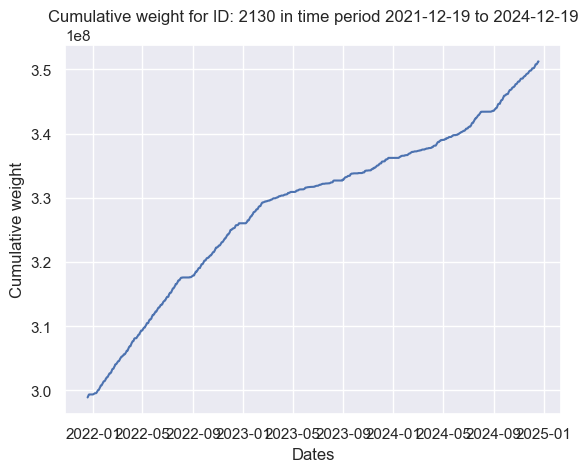

In [9]:
plot_id_simple(2130, last_three_years_df)

### Splitting the model for evaluation and validation 
From what we have seen in our data, there is a fair bit of time-dependancy and also some seasonality. We should consider both when validating our model.

We plan to split our data into
- train and test for training and validating our model.
- train_internal and eval_internal for internal validation by our model (rather than random cross-validation methods)

In [29]:
df_2130 = final_df[final_df["rm_id"] == 2130]

#Our first split for test data is 2024-09-01 to our last historical date (2024-12-19)
test_split_start = pd.Timestamp(year=2024, month=9, day=1).date()
#Our second split (for internal model validation) is 2024-01-01 to 2024-05-01
eval_split_start = pd.Timestamp(year=2024, month=1, day=1).date()
eval_split_end = pd.Timestamp(year=2024, month=5, day=1).date()

train_full_2030 = df_2130[df_2130["date"].dt.date < test_split_start]
test_holdout_2030 = df_2130[df_2130["date"].dt.date >= test_split_start]

train_internal_2030 = train_full_2030[train_full_2030["date"].dt.date < eval_split_start]
eval_internal_2030 = train_full_2030[(train_full_2030["date"].dt.date >= eval_split_start) & (train_full_2030["date"].dt.date <= eval_split_end) ]

#Verify:
print("train_full starts at ",train_full_2030["date"].dt.date.min() , "and ends at ", train_full_2030["date"].dt.date.max())
print("test_holdout starts at ", test_holdout_2030["date"].dt.date.min(), "and ends at ", test_holdout_2030["date"].dt.date.max())
print("train_internal starts at ",train_internal_2030["date"].dt.date.min() , "and ends at ",train_internal_2030["date"].dt.date.max() )
print("eval_internal starts at ",eval_internal_2030["date"].dt.date.min() , "and ends at ", eval_internal_2030["date"].dt.date.max())

train_full starts at  2004-06-15 and ends at  2024-08-31
test_holdout starts at  2024-09-01 and ends at  2024-12-19
train_internal starts at  2004-06-15 and ends at  2023-12-31
eval_internal starts at  2024-01-01 and ends at  2024-05-01


# Model considerations:
When creating our model, we have some options, each with their own pro's and con's. Different approaches might be suitable for different ID's
### Option 1. Modelling Increments and sum later for cumulative weight
- Might capture receival dynamics
- Scale of individual receivals might be easier for some models to handle
- For some ID's with many zeroes it can be hard to make good predictions.
- Hard to pinpoint exact receival dates. Can be extra detrimental since overestimation penalization is skewed.
### Option 2. Modelling increments but recursivly calculating cumulative weight for internal validation. WE WILL NOT IMPLEMENT THIS!
- Perhaps some of the benefits of Option 1
- Recursion during model prediction and training is likely to be very slow.
### Option 3. Modelling Cumulative weights directly
- In line with final submission
- Cares less about exact timing of receivals
- Might not catch receival mechanics
### Option 4. Model averages and distribute later (using option 3 as baseline)
- Since pinpointing dates are hard (at least for some ID's), we might have bad "daily prediction" but have a good idea for sum of predictions over a larger window.
- Distributing can be done unevenly (since overestimation is penalized more we can "backload" the distribution).
- Window sizes can be determined by frequency of deliveries
- Might be too generalizing, and not capture details.

### We decide what features should be used for predictions:

In [49]:
feature_columns = [
    "day_of_week", 
    "month", 
    "is_holiday",
    ]

# Preparing Dataframe for prediction:

In [ ]:
def prepare_common_df(df_for_prediction, start_date, end_date):

    prediction_range = pd.date_range(start=start_date, end=end_date)

    #Generic time-series data
    test_map = pd.DataFrame({"date" : prediction_range})
    test_map["day_of_week"] = test_map["date"].dt.dayofweek
    test_map["month"] = test_map["date"].dt.month

    #Get all holidays
    years = list(range(2023, 2025))
    all_holidays = holidays.Norway(years = years)
    #Convert type
    all_holidays = list(all_holidays.keys())
    all_holidays = pd.to_datetime(all_holidays)
    #Mark holidays
    test_map["is_holiday"] = test_map["date"].isin(all_holidays)
    test_map["is_holiday"] = test_map["is_holiday"].astype(int)

    return test_map


start_date = test_holdout_2030["date"].dt.date.min()
end_date = test_holdout_2030["date"].dt.date.max()
test_map = prepare_common_df(test_holdout_2030, start_date, end_date)


        date  day_of_week  month  is_holiday
0 2024-09-01            6      9           0
1 2024-09-02            0      9           0
2 2024-09-03            1      9           0
3 2024-09-04            2      9           0
4 2024-09-05            3      9           0


## Initialize model:


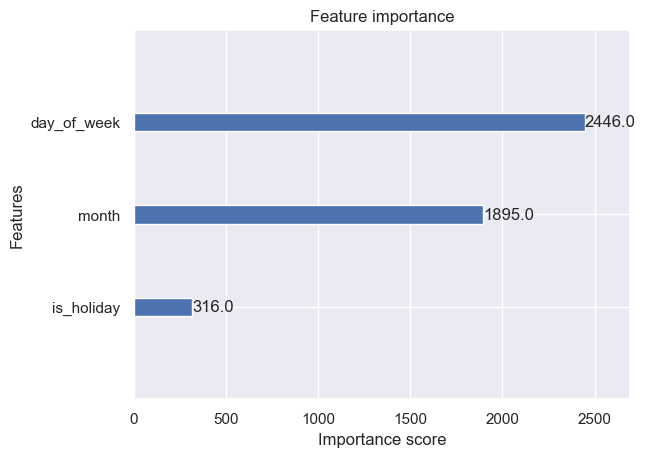

In [50]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1
)

X_train_internal = train_internal_2030[feature_columns]
y_train_internal = train_internal_2030["cumulative_weight"]
X_eval_internal = eval_internal_2030[feature_columns]
y_eval_internal = eval_internal_2030["cumulative_weight"]

xgb_model.fit(X_train_internal, y_train_internal, eval_set=[(X_eval_internal, y_eval_internal)], verbose=False)
#xgb_model = xgb.train(params, dtrain, num_boost_round=100)
#xgb_model = xgb.train(params, dtrain, num_boost_round=100, obj=quantile_objective())
xgb.plot_importance(xgb_model)
plt.show()

In [53]:
predictions = xgb_model.predict(test_map[feature_columns])

prediction_map = pd.DataFrame({"date" : test_map["date"]})
prediction_map["predictions"] = predictions

print(prediction_map.head())

        date  predictions
0 2024-09-01  107708968.0
1 2024-09-02  107181848.0
2 2024-09-03  106961376.0
3 2024-09-04  108259984.0
4 2024-09-05  108173192.0


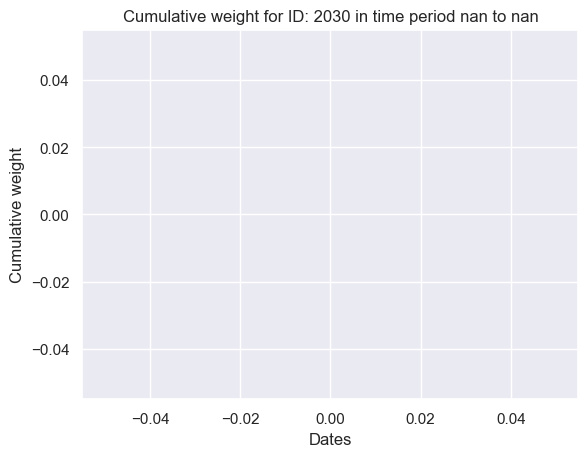

In [56]:
plot_id_simple(2030, final_df)